In [48]:
# ---------------------------------------------
# Import Required Libraries (All in syllabus)
# ---------------------------------------------

import pandas as pd               # For loading, cleaning, and manipulating data
import numpy as np                # For numerical operations
import matplotlib.pyplot as plt   # For data visualization (basic)
import seaborn as sns             # For advanced visualization
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For encoding & scaling
from sklearn.model_selection import train_test_split             # For splitting data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For evaluation


In [49]:
# ---------------------------------------------
#  Step 2: Load the Dataset and Convert to CSV
# ---------------------------------------------

# Load the .txt file 
data = pd.read_csv("C:\\Users\\acre\\Downloads\\KDDTrain+.txt\\KDDTrain+.txt", header=None)

# Save as .csv file
data.to_csv("KDDTrain_converted.csv", index=False)

# Display first few rows
print(" Dataset Loaded Successfully!")
# ---------------------------------------------
# Step 2.1: Add Column Names
# ---------------------------------------------
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
    "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","level"
]

data.columns = columns  # assign names
print("Column names added successfully!")
data.head()


 Dataset Loaded Successfully!
Column names added successfully!


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [50]:
#  Step 3.1 — Check for Missing Values
# This step helps us identify if any column has missing (null) values.
# If we find missing values, we can decide to fill them or drop the rows.
# Here, 0 means there are no missing values — so our data is clean.
print(" Checking for missing values in the dataset...\n")
missing_values = data.isnull().sum()
print(missing_values)
# All columns show 0 missing values → dataset is complete and clean.


 Checking for missing values in the dataset...

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate               

In [51]:
#  Step 3.2 — Check current label types before cleaning

# Shows all unique values in the 'label' column
data['label'].unique()


array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl'], dtype=object)

In [52]:
#  Step 3.3 — Convert all attack types into 'attack' label

print(" Converting all attack types to 'attack' and keeping 'normal' as is...\n")

data['label'] = data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

print(" Conversion completed!")
print("\nUnique values after conversion:")
print(data['label'].unique())


 Converting all attack types to 'attack' and keeping 'normal' as is...

 Conversion completed!

Unique values after conversion:
['normal' 'attack']


 Checking the distribution of 'normal' vs 'attack' records...

label
normal    67343
attack    58630
Name: count, dtype: int64


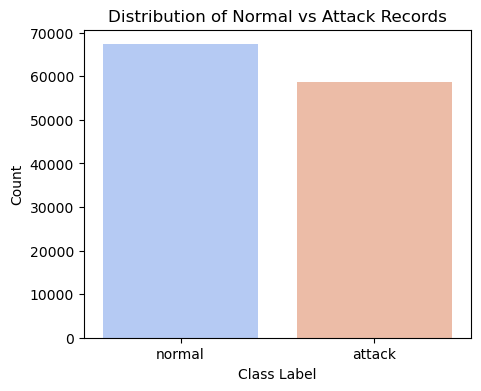

In [53]:
# Step 3.4 — Check Class Distribution (Normal vs Attack)

#  Using pandas for counting class values in target column ('label')
print(" Checking the distribution of 'normal' vs 'attack' records...\n")
class_counts = data['label'].value_counts()  # Counts each class occurrence
print(class_counts)  # Print how many normal and attack rows we have

#  Using Matplotlib and Seaborn for visualization
# Matplotlib → Controls figure size, title, labels
# Seaborn → Creates beautiful and easy count plot

plt.figure(figsize=(5,4))  # Set the graph size
sns.countplot(x='label', hue='label', data=data, palette='coolwarm', legend=False)  # Bar plot for label counts
plt.title('Distribution of Normal vs Attack Records')  # Title for better understanding
plt.xlabel('Class Label')  # X-axis label
plt.ylabel('Count')        # Y-axis label
plt.show()  # Show the graph


In [54]:
#  The dataset has been successfully simplified into two categories:
#    - 'normal'  → normal network activity
#    - 'attack'  → all types of attacks grouped together
# 
# The class counts show that the dataset is relatively balanced,
# which helps our machine learning models learn fairly without bias.

In [55]:
#  Step 3.5 — Identify and Encode Categorical Columns
# ----------------------------------------------------
#  Goal: Machine learning models work only with numbers, 
# so we need to convert text-based (categorical) columns into numeric form.

print(" Checking for categorical (non-numeric) columns...\n")

# This will list all columns that contain non-numeric (object) values
categorical_cols = data.select_dtypes(include=['object']).columns
print("Categorical columns found:\n", categorical_cols)

# Expected output:
# ['protocol_type', 'service', 'flag', 'label']

# Note: 'label' is our target variable (Normal/Attack), 
# so we do NOT encode it here — only the first three.

# -----------------------------------------
#  Encode Categorical Columns using LabelEncoder
# -----------------------------------------
from sklearn.preprocessing import LabelEncoder  # from scikit-learn: used for encoding text labels into numbers

# Create encoder object
encoder = LabelEncoder()

# Apply encoding to each categorical input column (except 'label')
for col in ['protocol_type', 'service', 'flag']:
    data[col] = encoder.fit_transform(data[col])  #fit() → Looks at all unique values in that column (e.g. 'tcp', 'udp', 'icmp')
#transform() → Replaces all those text values with their new numeric codes.
print("\n Encoding completed for categorical columns: ['protocol_type', 'service', 'flag']")

# Display first 5 rows to verify changes
print("\n Preview after encoding:")
print(data.head())


 Checking for categorical (non-numeric) columns...

Categorical columns found:
 Index(['protocol_type', 'service', 'flag', 'label'], dtype='object')

 Encoding completed for categorical columns: ['protocol_type', 'service', 'flag']

 Preview after encoding:
   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0              1       20     9        491          0     0   
1         0              2       44     9        146          0     0   
2         0              1       49     5          0          0     0   
3         0              1       24     9        232       8153     0   
4         0              1       24     9        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                

 Detecting outliers using Z-score and visualizing them...

Total outlier rows detected: 10118


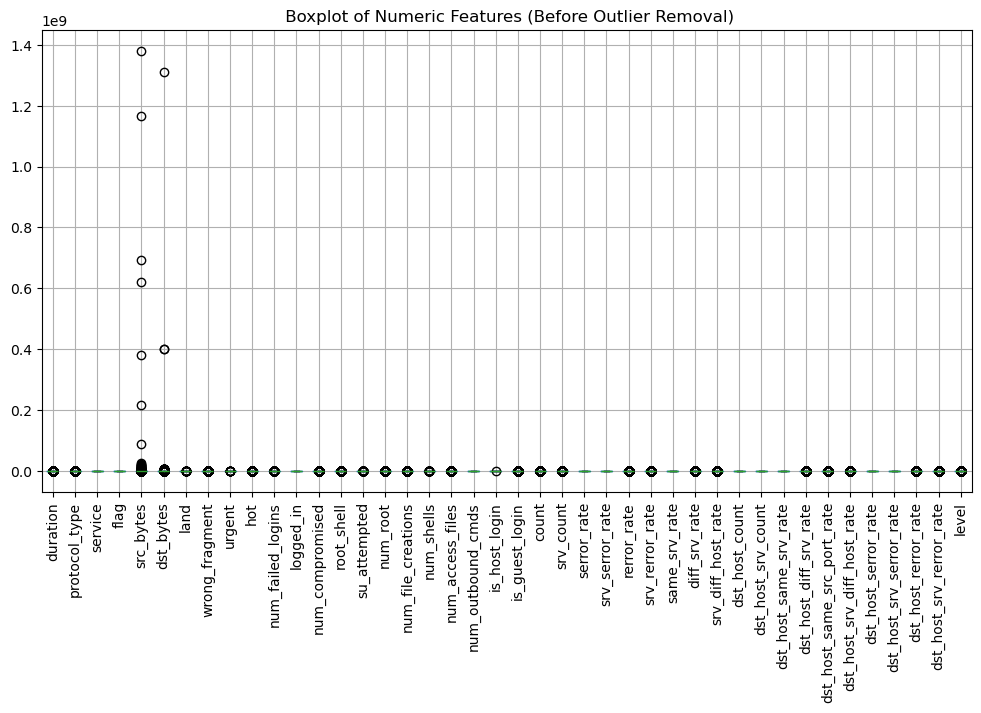


 Outlier removal complete.
Before cleaning: 125973 rows
After cleaning:  115855 rows
Removed:         10118 rows (outliers)


In [56]:

# ---------------------------------------------
#  Step 3.6 — Detect and visualize outliers using Z-score
# ---------------------------------------------

# Libraries used:
# numpy -> for numerical operations
# scipy.stats -> for Z-score calculation
# matplotlib & seaborn -> for boxplots (visual outlier detection)

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" Detecting outliers using Z-score and visualizing them...\n")

# Select only numeric columns for analysis
numeric_cols = data.select_dtypes(include=[np.number]).columns

# Step 1: Calculate Z-scores for all numeric columns
z_scores = np.abs(stats.zscore(data[numeric_cols]))

# Step 2: Define a threshold value
threshold = 5  # values with z-score > 5 will be treated as outliers

# Step 3: Count how many rows are outliers
outlier_rows = (z_scores > threshold).any(axis=1)
print(f"Total outlier rows detected: {outlier_rows.sum()}")

# Step 4: Visualize outliers for a few numeric columns using boxplots
plt.figure(figsize=(12, 6))
data[numeric_cols].boxplot()
plt.title(" Boxplot of Numeric Features (Before Outlier Removal)")
plt.xticks(rotation=90)
plt.show()

# Step 5: (Optional) Remove outliers if needed
data_cleaned = data[~outlier_rows]

print(f"\n Outlier removal complete.")
print(f"Before cleaning: {len(data)} rows")
print(f"After cleaning:  {len(data_cleaned)} rows")
print(f"Removed:         {len(data) - len(data_cleaned)} rows (outliers)")


In [57]:

# --------------------------------------------------------
# Step 4 - Feature Scaling (Standardization)
# --------------------------------------------------------
# Libraries used:
# - StandardScaler (from sklearn.preprocessing): Used to scale all numerical features.
#   It ensures that each feature contributes equally to the model by giving them similar ranges.
# - pandas: To handle the dataset in DataFrame format.
# --------------------------------------------------------

from sklearn.preprocessing import StandardScaler  # Importing StandardScaler for scaling the features

# Display message for clarity
print("Performing feature scaling using StandardScaler...")

# Separate the dataset into features (X) and target label (y)
# 'X' contains all columns except 'label' (independent variables)
# 'y' contains only the 'label' column (the value we want to predict)
X = data.drop(columns=['label'])
y = data['label']

# Create an object of StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and then transform them
# This standardizes the data so that each feature has a mean of 0 and standard deviation of 1
X_scaled = scaler.fit_transform(X)

# Convert the scaled data (which is in array form) back to a pandas DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display confirmation message
print("Feature scaling completed successfully.")
print()

# Display first 5 rows to see the scaled values
print("First 5 rows after scaling:")
print(X_scaled.head())


Performing feature scaling using StandardScaler...
Feature scaling completed successfully.

First 5 rows after scaling:
   duration  protocol_type   service      flag  src_bytes  dst_bytes  \
0 -0.110249      -0.124706 -0.686785  0.751111  -0.007679  -0.004919   
1 -0.110249       2.219312  0.781428  0.751111  -0.007737  -0.004919   
2 -0.110249      -0.124706  1.087305 -0.736235  -0.007762  -0.004919   
3 -0.110249      -0.124706 -0.442083  0.751111  -0.007723  -0.002891   
4 -0.110249      -0.124706 -0.442083  0.751111  -0.007728  -0.004814   

       land  wrong_fragment    urgent       hot  ...  dst_host_srv_count  \
0 -0.014089       -0.089486 -0.007736 -0.095076  ...           -0.818890   
1 -0.014089       -0.089486 -0.007736 -0.095076  ...           -1.035688   
2 -0.014089       -0.089486 -0.007736 -0.095076  ...           -0.809857   
3 -0.014089       -0.089486 -0.007736 -0.095076  ...            1.258754   
4 -0.014089       -0.089486 -0.007736 -0.095076  ...            1.2

In [58]:
# --------------------------------------------------------
# Step 5 — Splitting the Dataset into Training and Testing Sets
# --------------------------------------------------------
# Libraries used:
# - train_test_split (from sklearn.model_selection): 
#   Used to divide the dataset into two parts — one for training (to learn) 
#   and one for testing (to check model accuracy)
# --------------------------------------------------------

from sklearn.model_selection import train_test_split  # Import function to split data

# Message for understanding
print("Splitting the dataset into training and testing sets...\n")

# X_scaled → contains all the features (input data)
# y → contains the labels ('normal' or 'attack')

# Split the data:
# test_size = 0.2 means 20% of the data will be used for testing, 80% for training
# random_state = 42 is just to make sure results stay the same every time we run it
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Show the number of rows in each set
print("Training data size:", X_train.shape[0], "records")  # Number of rows used for training
print("Testing data size:", X_test.shape[0], "records")    # Number of rows used for testing
print()
print("Dataset successfully split into Training and Testing sets!")


Splitting the dataset into training and testing sets...

Training data size: 100778 records
Testing data size: 25195 records

Dataset successfully split into Training and Testing sets!


In [59]:
# --------------------------------------------------------
# Step 6 — Importing Machine Learning Libraries
# --------------------------------------------------------

# Models
from sklearn.linear_model import LogisticRegression      # Algorithm 1
from sklearn.tree import DecisionTreeClassifier           # Algorithm 2
from sklearn.ensemble import RandomForestClassifier       # Algorithm 3

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(" Libraries imported successfully for model training and evaluation.")


 Libraries imported successfully for model training and evaluation.


In [60]:
# --------------------------------------------------------
# Step 6.2 — Logistic Regression Model
# --------------------------------------------------------

# Logistic Regression is a simple and effective algorithm for binary classification problems.
# It tries to find the best fit line (decision boundary) to separate classes like 'normal' and 'attack'.

print(" Training Logistic Regression model...\n")

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)   # max_iter=1000 ensures the model converges (completes training)

# Train (fit) the model on training data
log_reg.fit(X_train, y_train)

print(" Model training completed!\n")

# --------------------------------------------------------
# Step 6.2.1 — Make Predictions on Test Data
# --------------------------------------------------------

# The model will now predict labels ('normal' or 'attack') for the unseen test data
y_pred_lr = log_reg.predict(X_test)

# --------------------------------------------------------
# Step 6.2.2 — Evaluate Model Performance
# --------------------------------------------------------

# Accuracy tells how many predictions were correct out of total predictions
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Confusion matrix shows how many normal/attack were correctly or incorrectly predicted
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# Classification report shows precision, recall, and f1-score for both classes
class_report_lr = classification_report(y_test, y_pred_lr)

# --------------------------------------------------------
# Step 6.2.3 — Display the Results
# --------------------------------------------------------

print("Logistic Regression Model Evaluation Results:\n")
print(f"Accuracy: {accuracy_lr:.4f}\n")   # .4f means show 4 decimal places

print("Confusion Matrix:")
print(conf_matrix_lr, "\n")

print("Classification Report:")
print(class_report_lr)


 Training Logistic Regression model...

 Model training completed!

Logistic Regression Model Evaluation Results:

Accuracy: 0.9781

Confusion Matrix:
[[11561   212]
 [  339 13083]] 

Classification Report:
              precision    recall  f1-score   support

      attack       0.97      0.98      0.98     11773
      normal       0.98      0.97      0.98     13422

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195



In [61]:
# --------------------------------------------------------
# Step 6.3 — Decision Tree Classifier
# --------------------------------------------------------
# Libraries used:
# - DecisionTreeClassifier: For building the decision tree model
# - accuracy_score, confusion_matrix, classification_report: For model evaluation
# --------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Training Decision Tree model...")

#  Create the model
# random_state → ensures reproducible results
# max_depth (optional) → limit tree size to avoid overfitting (you can experiment)
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)

#  Train (fit) the model on the training data
dt_model.fit(X_train, y_train)

print("\nModel training completed!\n")

#  Predict on the test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate model performance
print("Decision Tree Model Evaluation Results:\n")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", round(accuracy_dt, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Training Decision Tree model...

Model training completed!

Decision Tree Model Evaluation Results:

Accuracy: 0.9985

Confusion Matrix:
[[11752    21]
 [   18 13404]]

Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [62]:
# --------------------------------------------------------
# Step 6.4 — Random Forest Classifier
# --------------------------------------------------------
#  Libraries used:
# - RandomForestClassifier: For building an ensemble (collection) of decision trees
# - accuracy_score, confusion_matrix, classification_report: For model evaluation
# --------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Training Random Forest model...")

# Create the model
# n_estimators → number of trees in the forest
# random_state → ensures reproducible results
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#  Train (fit) the model on the training data
rf_model.fit(X_train, y_train)

print("\nModel training completed!\n")

# Predict on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate model performance
print("Random Forest Model Evaluation Results:\n")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", round(accuracy_rf, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Training Random Forest model...

Model training completed!

Random Forest Model Evaluation Results:

Accuracy: 0.9995

Confusion Matrix:
[[11765     8]
 [    4 13418]]

Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



Model Performance Comparison:
Logistic Regression Accuracy: 97.81%
Decision Tree Accuracy: 99.85%
Random Forest Accuracy: 99.95%


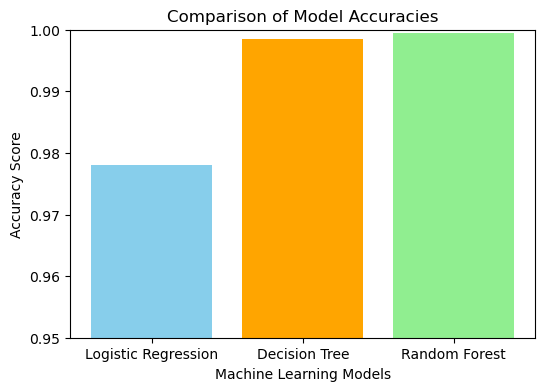


 Best Model: Random Forest with accuracy 99.95%


In [63]:
# --------------------------------------------------------
# Step 7 — Compare Model Accuracies
# --------------------------------------------------------

# Import library for plotting
import matplotlib.pyplot as plt

# Store model names and their accuracies
# (You can use the exact accuracy values you got in your outputs)
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [0.9781, 0.9985, 0.9995]

# Display the accuracy values in text form
print("Model Performance Comparison:")
for i in range(len(models)):
    print(f"{models[i]} Accuracy: {accuracies[i]*100:.2f}%")

# Create a bar chart to visualize model performance
plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['skyblue', 'orange', 'lightgreen'])
plt.title("Comparison of Model Accuracies")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.ylim(0.95, 1.0)  # Set y-axis range for clear comparison
plt.show()

# Print the best model based on highest accuracy
best_model_index = accuracies.index(max(accuracies))
print(f"\n Best Model: {models[best_model_index]} with accuracy {accuracies[best_model_index]*100:.2f}%")


In [71]:
# Step 7 — Manual Testing (Final Step)
# Purpose: To test the trained Random Forest model using a new sample input

# ------------------ Step 1: Check number of features ------------------
# This prints how many columns (features) your dataset has
print("Number of columns in X:", len(X.columns))

# ------------------ Step 2: Create a sample input ------------------
# NOTE: The number of values below must exactly match the number of columns in X
# Example: If X has 42 columns, you must provide 42 values below
sample_input = np.array([[0, 1, 2, 1, 491, 0, 0, 0, 0, 0,
                          0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                          123, 255, 1, 1, 0.1, 0.1, 0.0, 0.0,
                          0.0, 0.0, 255, 1, 0.1, 0.0, 0.0,
                          0.0, 255, 1, 0.1, 0.0, 0.0, 0.0]])  # 42 values

# ------------------ Step 3: Convert to DataFrame ------------------
# This gives your input the same column names as the training data
sample_df = pd.DataFrame(sample_input, columns=X.columns)

# ------------------ Step 4: Scale the sample input ------------------
# We scale the new input with the same StandardScaler used during training
sample_scaled = scaler.transform(sample_df)
sample_scaled = pd.DataFrame(sample_scaled, columns=X.columns)

# ------------------ Step 5: Make Prediction ------------------
# Use the Random Forest model (rf) for prediction because it gave the highest accuracy
prediction = rf.predict(sample_scaled)

# ------------------ Step 6: Display Output ------------------
# 0 = Normal Traffic, 1 = Attack Detected
if prediction[0] == 0:
    print(" Normal traffic detected.")
else:
    print(" Attack detected!")

# ------------------ Step 7: Explanation ------------------
# Random Forest is chosen here because it performed the best among all algorithms
# (It had the highest accuracy, best precision and recall)
# Therefore, it gives the most reliable final prediction for detecting attacks.


Number of columns in X: 42
 Attack detected!
